## 1. 프로젝트 : Data Labeling
위에서 배운 Data Labeling 4가지를 직접 적용해봅시다.

### ① Price Change Direction 적용하기
### ② Using Moving Average 적용하기
### ③ Local Min-Max 적용하기
### ④ Trend Scanning 적용하기

앞에서 진행한 Data Labeling 방법은 4가지가 있었습니다.

먼저 필요한 라이브러리 및 패키지를 확인 후 실행합니다. 다음은 데이터가 저장된 경로에서 데이터를 불러온 뒤 필요한 부분을 확인하기 위해 시각화를 진행합니다.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

<AxesSubplot:xlabel='time'>

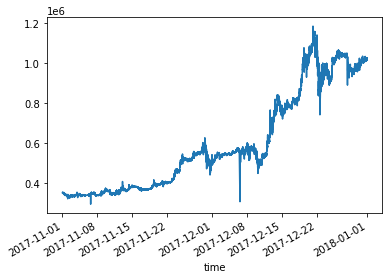

In [2]:
# 데이터 경로
DATA_PATH = '/aiffel/aiffel/fnguide/data/'

# 데이터 불러오기
modify_data = pd.read_csv(os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)

# 불러온 데이터 시각화하기
modify_data.loc['2017-11-01':'2017-12-31','close'].plot()

### ① Price Change Direction 적용하기 

 아래의 수식을 적용하여 momentum_signal을 만들어봅시다. 그리고 기존의 데이터(modify_data)와 수식이 적용된 데이터(momentum_signal)를 시각화하여 어떤 차이가 있는지 비교해봅시다.
Labeli(t) = { 1,if price_t−price_{t−n} > 0 
              0,if else


 먼저 window를 설정합니다. 보통 window는 시계열 데이터에서 이전 시점과 현재 시점간의 간격을 구간별로 잘라서 사용하곤 합니다. 이렇게 사용하는 이유는 정확한 예측을 달성하기 위해 우리가 가지고 있는 정보를 과거로부터 주어진 시점에서 가능한 안전하게 보존된 정보를 모델에 제공하기 위해 Window로 다시 구성한 다음 모델에 input으로 주입하는 것입니다. window는 보통 time series data 외에도 많이 사용하는 기법입니다.(ex. 정렬 알고리즘, CNN의 sliding 등...)

In [3]:
# Q. 코드를 작성해주세요

# window 지정
window = 10 # 앞서 사용한 window의 값은 10입니다.

# momentum_signal 만들기
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].shift(window)) + 1) # modify_data['close'].shift(window)활용

# s_momentum_signal 만들기
s_momentum_signal = pd.Series(
    momentum_signal,
    index=modify_data.index,
    name='price_change_direction'
) # 데이터 활용을 위해 pd.Series를 사용합니다.

# 데이터프레임에 추가
modify_data['price_change_direction'] = s_momentum_signal # 이걸 추가해야 아래 종가 가져오고 오류가 나지 않음

기존의 데이터(modify_data)에서 필요한 close(종가)를 가져오고 수식이 적용된 데이터(s_momentum_signal)의 종가와 얼마나 차이가 있는지 확인하기 위해 데이터를 변환하고 시각화합니다.

In [4]:
# Q. 코드를 작성해주세요

# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21':, 'close'] # loc를 활용하여 2017-11-21부터 close(종가)까지 가져오기

# 수식 적용된 데이터 만들기
c_sig = modify_data.loc['2017-11-21':,  ['close', 'price_change_direction']].copy() # loc를 활용하여 2017-11-21의 시간대별 값을 가져오기

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] =np.where(
    c_sig['price_change_direction'] == 1,
    'red',      # 상승
    'blue'      # 하락
) # np.where 사용

# 시각화하기
plt.figure(figsize=(15,6))

<Figure size 1080x432 with 0 Axes>

<Figure size 1080x432 with 0 Axes>

## 해석

⚫ 검은 선 → 실제 가격 흐름

🔴 빨간 점 → window(10) 기준 상승

🔵 파란 점 → window(10) 기준 하락

### ② Using Moving Average 적용하기

In [5]:
# Q. 코드를 작성해주세요

# momentum_signal(현재 가격 - 이동평균)
momentum_signal = np.sign(np.sign(modify_data['close'] - 
        modify_data['close'].rolling(window).mean()) + 1) # modify_data['close'].rolling(window).mean() 활용

# s_momentum_signal
s_momentum_signal = pd.Series(
    momentum_signal,
    index=modify_data.index,
    name='ma_price_direction'
) # pd.Series로 변환

# 데이터프레임에 추가
modify_data['ma_price_direction'] = s_momentum_signal

앞서 "① Price Change Direction 적용하기"에서 진행했던 것처럼 시각화를 위해 Using Moving Average 수식을 적용한 것과 비교하기 위해 데이터를 변환하여 시각화를 통해 확인합니다.

In [6]:
# Q. 코드를 작성해주세요

# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21':, 'close']

# 수식 적용된 데이터 만들기
c_sig = modify_data.loc['2017-11-21':, 
                        ['close', 'ma_price_direction']].copy()

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] = np.where(
    c_sig['ma_price_direction'] == 1,
    'red',      # 이동평균 위 (상승)
    'blue'      # 이동평균 아래 (하락)
)

# 시각화하기
plt.figure(figsize=(15,6))

<Figure size 1080x432 with 0 Axes>

<Figure size 1080x432 with 0 Axes>

## 해석

⚫ 검은 선 → 실제 가격

🔴 빨간 점 → 가격이 이동평균 위

🔵 파란 점 → 가격이 이동평균 아래

## ①과 ②의 차이

방법
1. Price Change Direction: 기준이 과거 가격과 비교
2. Moving Average: 기준이 평균 추세와 비교

- Moving Average 방식이 더 추세 중심적입니다.

### ③ Local Min-Max 적용하기

최소 - 최대 구간을 이어나가며 Labeling하는 함수를 아래 수도코드(pseudo-code)를 보고 만들어봅시다.

- 𝐼𝑛𝑖𝑡𝑖𝑎𝑙𝑖𝑧𝑒 𝑣𝑎𝑟𝑖𝑎𝑏𝑙𝑒𝑠𝑓𝑜𝑟 𝑖 𝑖𝑛 𝑑𝑎𝑡𝑎𝑠𝑒𝑡:
     - 𝑖𝑓 𝑐𝑢𝑟𝑟𝑒𝑛𝑡𝑝𝑟𝑖𝑐𝑒<𝑝𝑟𝑒𝑣𝑖𝑜𝑢𝑠𝑚𝑖𝑛𝑝𝑟𝑖𝑐𝑒
        𝑚𝑖𝑛𝑝𝑟𝑖𝑐𝑒←𝑐𝑢𝑟𝑟𝑒𝑛𝑡𝑝𝑟𝑖𝑐𝑒
        𝑝𝑎𝑠𝑠𝑖𝑛𝑔 𝑡ℎ𝑟𝑜𝑢𝑔ℎ 𝑡ℎ𝑒 𝐹𝑎𝑙𝑙𝑖𝑛𝑔 𝑇𝑟𝑒𝑛𝑑
        𝑎𝑐𝑐𝑢𝑚𝑢𝑙𝑎𝑡𝑒𝑠𝑚𝑖𝑛𝑝𝑟𝑖𝑐𝑒
      - 𝑖𝑓 𝑐𝑢𝑟𝑟𝑒𝑛𝑡𝑝𝑟𝑖𝑐𝑒>𝑝𝑟𝑒𝑣𝑖𝑜𝑢𝑠𝑚𝑎𝑥𝑝𝑟𝑖𝑐𝑒
        𝑚𝑎𝑥𝑝𝑟𝑖𝑐𝑒←𝑐𝑢𝑟𝑟𝑒𝑛𝑡𝑝𝑟𝑖𝑐𝑒
        𝑝𝑎𝑠𝑠𝑖𝑛𝑔 𝑡ℎ𝑟𝑜𝑢𝑔ℎ 𝑡ℎ𝑒 𝑅𝑖𝑠𝑖𝑛𝑔 𝑇𝑟𝑒𝑛𝑑
        𝑎𝑐𝑐𝑢𝑚𝑢𝑙𝑎𝑡𝑒𝑠𝑚𝑎𝑥𝑝𝑟𝑖𝑐𝑒
      - 𝑖𝑓 𝑒𝑛𝑑𝑠 𝑡ℎ𝑒 𝐹𝑎𝑙𝑙𝑖𝑛𝑔 𝑇𝑟𝑒𝑛𝑑
        𝑚𝑎𝑥𝑝𝑟𝑖𝑐𝑒←𝑚𝑖𝑛𝑝𝑟𝑖𝑐𝑒
      - 𝑖𝑓 𝑒𝑛𝑑𝑠 𝑡ℎ𝑒 𝑅𝑖𝑠𝑖𝑛𝑔 𝑇𝑟𝑒𝑛𝑑
        𝑚𝑖𝑛𝑝𝑟𝑖𝑐𝑒←𝑚𝑎𝑥𝑝𝑟𝑖𝑐𝑒


①~⑦까지 코드를 자세히 들여다보고 어떠한 방식으로 코드가 동작되는지 뜯어봅시다. ⑧ return 값은 dictionary 형태로 2개의 DataFrame이 반환되어야합니다.

이 알고리즘은

- 가격이 계속 내려가면 → Falling trend → min 갱신

- 가격이 계속 올라가면 → Rising trend → max 갱신

- 일정 기간(wait) 갱신이 없으면 → 추세 전환

이라는 구조입니다.

In [7]:
# Local min / max 를 추출하기 위한 함수
def get_local_min_max(close, wait=3):
    min_value = close.iloc[0]
    max_value = close.iloc[0]   # ① 초기 max_value도 첫 가격으로 시작
    n_cnt_min, n_cnt_max = 0, 0
    
    mins, maxes = [], []
    min_idxes, max_idxes = [], []
    b_min_update, b_max_update = False, False
    
    for idx, val in zip(close.index[1:], close.values[1:]):
        
        # 새로운 최소값
        if val < min_value:
            min_value = val
            mins.append(min_value)
            min_idxes.append(idx)
            n_cnt_min = 0
            b_min_update = True
        
        # 새로운 최대값
        if val > max_value:
            max_value = val                # ② 새로운 고점이 나오면 max_value 갱신
            maxes.append(max_value)        # ③ 리스트에 저장
            max_idxes.append(idx)
            n_cnt_max = 0
            b_max_update = True            # ④ max 갱신 플래그 True
        
        # Falling trend 유지 확인           # 고점 갱신이 없으면 → 하락 추세로 판단, min 카운트 증가, wait 이상 지속되면 추세 전환
        if not b_max_update:
            b_min_update = False
            n_cnt_min += 1
            if n_cnt_min >= wait:
                max_value = min_value
                n_cnt_min = 0
        
        # Rising trend 유지 확인
        if not b_min_update:
            b_max_update = False           # ⑤ 최소값 갱신이 없으면 상승 추세로 판단
            n_cnt_max += 1                 # ⑥ max 카운트 증가
            if n_cnt_max >= wait:
                min_value = max_value      # ⑦ wait 이상 지속되면 추세 전환
                n_cnt_max = 0
               
    return {                               # ⑧ 결과
        "min": pd.DataFrame({
            "index": min_idxes,
            "price": mins
        }),
        "max": pd.DataFrame({
            "index": max_idxes,
            "price": maxes
        })
    }

get_local_min_max 함수를 사용하면 return 값이 2개가 나오게 됩니다. 아래 주석을 제거하여 min과 maxes의 값이 어떻게 나오는지 확인해봅시다.

In [8]:
# Local mins, maxes를 확인 
mins, maxes = get_local_min_max(sub_data, wait=3) 

# mins, maxes 확인 
print(mins) 
print('--'*20) 
print(maxes)

min
----------------------------------------
max


노드 코드로는 프린트 되지않음 -> 작성한 함수가 dictionary 하나를 반환하는데 기존 노드에서는 2개로 언패킹하려고 하고 있어서 오류가 남 그래서 딕셔너리 형태로 변경해주기

In [9]:
result = get_local_min_max(sub_data, wait=3)

mins = result['min']
maxes = result['max']

print(mins)
print('--'*20)
print(maxes)

                     index   price
0      2017-11-21 00:01:00  399050
1      2017-11-21 00:03:00  399000
2      2017-11-21 00:04:00  398900
3      2017-11-21 00:05:00  398850
4      2017-11-21 00:06:00  398800
...                    ...     ...
293188 2019-11-03 10:26:00  212700
293189 2019-11-03 10:30:00  212600
293190 2019-11-03 10:31:00  212400
293191 2019-11-03 10:32:00  212500
293192 2019-11-03 10:33:00  212350

[293193 rows x 2 columns]
----------------------------------------
                     index   price
0      2017-11-21 00:13:00  399500
1      2017-11-21 00:14:00  399900
2      2017-11-21 00:16:00  401450
3      2017-11-21 00:19:00  401350
4      2017-11-21 00:20:00  401500
...                    ...     ...
236563 2019-11-03 09:54:00  213650
236564 2019-11-03 10:03:00  213750
236565 2019-11-03 10:12:00  213400
236566 2019-11-03 10:13:00  213550
236567 2019-11-03 10:29:00  212800

[236568 rows x 2 columns]


(91545.3, 2453290.0)

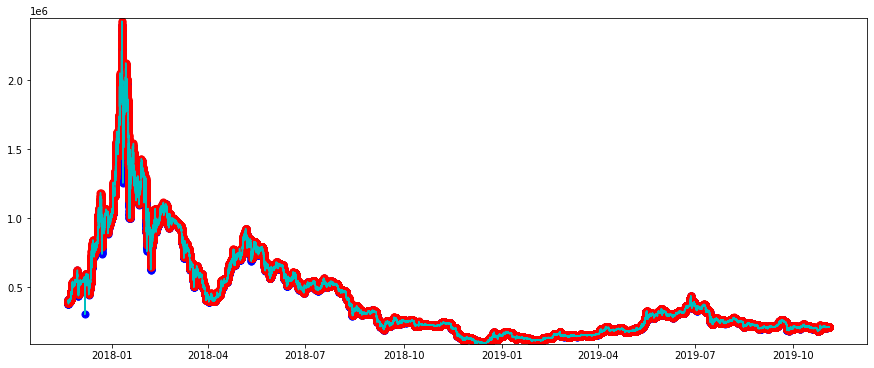

In [10]:
# Q. 코드를 작성해주세요
# subplots 및 plot 생성
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(sub_data, 'c')

# min_time, local_min을 활용한 scatter plot 생성
ax.scatter(
    mins['index'],
    mins['price'],
    color='blue',
    s=50,
    label='Local Min'
)

# max_time, local_max를 활용한 scatter plot 생성
ax.scatter(
    maxes['index'],
    maxes['price'],
    color='red',
    s=50,
    label='Local Max'
)

# y축 설정
ax.set_ylim([sub_data.min() * 0.99, sub_data.max() * 1.01])

### 해석

청록색 선 → 전체 가격 흐름, 점과 점 사이가 하나의 추세 구간

🔵 파란 점 → Local Min (저점), 바닥 형성 구간

🔴 빨간 점 → Local Max (고점), 고점 형성 구간

즉, 상승과 하락이 전환되는 지점을 시각적으로 확인하는 과정

### ④ Trend Scanning 적용하기
- Trend Scanning을 구현하기
- OLS는 회귀분석을 하는 경우 유용하게 사용할 수 있으며 아래 함수에서 ols.tvalue를 통해 t-value값을 사용할 수 있는 함수를 활용하여 추세(trend)를 추정합니다.

In [11]:
def t_val_lin_r(close):
    import statsmodels.api as sml
    
    # t-value from a linear trend
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sml.OLS(close, x).fit() 
    return ols.tvalues[1]

In [12]:
look_forward_window = 60
min_sample_length = 5
step = 1
t1_array = []
t_values_array = []

In [13]:
# 이 코드 블럭은 실행에 20-30분정도가 소요될 수 있습니다.

molecule = modify_data['2017-11-01':'2017-11-30'].index
label = pd.DataFrame(index=molecule, columns=['t1', 't_val', 'bin'])
tmp_out = []

for ind in tqdm(molecule):
    subset = modify_data.loc[ind:, 'close'].iloc[:look_forward_window]
    
    if look_forward_window > subset.shape[0]:
        continue
    
    tmp_subset = pd.Series(index=subset.index[min_sample_length-1:subset.shape[0]-1])
    tval = []

    # 회귀분석을 통해 t 통계량값을 이용하여 추세 추정
    for forward_window in np.arange(min_sample_length, subset.shape[0]):
        df = subset.iloc[:forward_window]
        tval.append(t_val_lin_r(df.values))  # t-value 계산
    
    tmp_subset.loc[tmp_subset.index] = np.array(tval)
    
    idx_max = tmp_subset.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
    tmp_t_val = tmp_subset[idx_max]
    
    tmp_out.append([
        tmp_subset.index[-1],   # t1 (종료 시점)
        tmp_t_val,              # t-value
        np.sign(tmp_t_val)      # 방향 (상승=1, 하락=-1)
    ])

# leakage 방지
label.loc[molecule] = np.array(tmp_out) # prevent leakage

label['t1'] = pd.to_datetime(label['t1'])
label['bin'] = pd.to_numeric(label['bin'], downcast='signed')

100%|██████████| 33384/33384 [14:11<00:00, 39.22it/s]


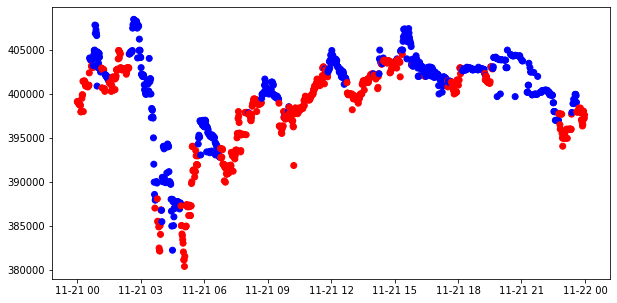

In [14]:
# 시각화
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = label['bin'].loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(sub_data.index, sub_data.values, c=c_sig['color'])

## 2. 프로젝트 : Feature Engineering
### ① 환경구성 및 데이터 불러오기
### ② Technical Index 적용하기
### ③ Feature Selection methods 적용하기



### ① 환경구성 및 데이터 불러오기
- 환경구성 및 데이터를 불러옵니다.

In [15]:
!pip install ta==0.9.0
!pip install shap

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.9.0-py3-none-any.whl size=28907 sha256=29043263573f55cd5890d111fb2337d41bb1286bb60547962f1b7e80a37bc7ef
  Stored in directory: /aiffel/.cache/pip/wheels/d1/3c/c4/176cfd752bd625c697799269715459e85c6dfd9500df26ad93
Successfully built ta
     |████████████████████████████████| 999 kB 7.7 MB/s            
     |████████████████████████████████| 3.7 MB 55.8 MB/s            
     |████████████████████████████████| 19.5 MB 45.1 MB/s            
     |████████████████████████████████| 43.9 MB 61 kB/s              
     |████████████████████████████████| 16.8 MB 61.8 MB/s            
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.4
    Uninstalling numpy-1.21.4:
      Successfully uninstalled numpy-1.21.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.36.0
    Uninstalling llvmlite-0.36.0:
      Successfully uninstalled llvmlite-0.36.0
  Attempting uninstall: n

In [16]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

import sys
sys.path.append('/aiffel/aiffel/fnguide/data/')
from libs.feature_importance import importance as imp
from sklearn.feature_selection import SequentialFeatureSelector, RFECV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [17]:
# 데이터 경로 설정
DATA_PATH = '/aiffel/aiffel/fnguide/data/'
anno_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick_label.pkl')
target_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv')

# 데이터 불러오기
df_modify_data = pd.read_csv(target_file_name, index_col=0, parse_dates=True)
df_label_data = pd.read_pickle(anno_file_name)
df_sub_modify_data = df_modify_data.loc[df_label_data.index]

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
df_sub_modify_data = df_sub_modify_data.iloc[:1000]

### ② Technical Index 적용하기
- 앞서 배운 기술적 지표와 수익률/변동성 지표를 참고하여 코드를 뜯어봅시다.

In [18]:
# 기술적 지표를 적용합니다.

mt = 1
fillna = False
df_ = df_sub_modify_data.copy()
open, high, low, close, volume = 'open', 'high', 'low', 'close', 'volume'
cols = [open, high, low, close, volume]

## Volume Index
# Chaikin Money Flow
df_["volume_cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
                        high=df_[high], low=df_[low], close=df_[close], volume=df_[volume], window=20*mt, fillna=fillna
                    ).chaikin_money_flow()
# Force Index
df_["volume_fi"] = ta.volume.ForceIndexIndicator(
                        close=df_[close], volume=df_[volume], window=15*mt, fillna=fillna
                    ).force_index()
# Money Flow Indicator
df_["volume_mfi"] = ta.volume.MFIIndicator(
                        high=df_[high],
                        low=df_[low],
                        close=df_[close],
                        volume=df_[volume],
                        window=15*mt,
                        fillna=fillna,
                    ).money_flow_index()
# Ease of Movement
df_["volume_sma_em"] = ta.volume.EaseOfMovementIndicator(
                            high=df_[high], low=df_[low], volume=df_[volume], window=15*mt, fillna=fillna
                        ).sma_ease_of_movement()

# Volume Price Trend
df_["volume_vpt"] = ta.volume.VolumePriceTrendIndicator(
                        close=df_[close], volume=df_[volume], fillna=fillna
                    ).volume_price_trend()

## volatility index
# Average True Range
df_["volatility_atr"] = ta.volatility.AverageTrueRange(
                            close=df_[close], high=df_[high], low=df_[low], window=10*mt, fillna=fillna
                        ).average_true_range()

# Ulcer Index
df_["volatility_ui"] = ta.volatility.UlcerIndex(
                            close=df_[close], window=15*mt, fillna=fillna
                        ).ulcer_index()

## trend index
# MACD
df_["trend_macd_diff"] = ta.trend.MACD(
                            close=df_[close], window_slow=25*mt, window_fast=10*mt, window_sign=9, fillna=fillna
                        ).macd_diff()

# Average Directional Movement Index (ADX)
df_["trend_adx"] = ta.trend.ADXIndicator(
                        high=df_[high], low=df_[low], close=df_[close], window=15*mt, fillna=fillna
                    ).adx()

# TRIX Indicator
df_["trend_trix"] = ta.trend.TRIXIndicator(
                        close=df_[close], window=15*mt, fillna=fillna
                    ).trix()

# Mass Index
df_["trend_mass_index"] = ta.trend.MassIndex(
                            high=df_[high], low=df_[low], window_fast=10*mt, window_slow=25*mt, fillna=fillna
                        ).mass_index()

# DPO Indicator
df_["trend_dpo"] = ta.trend.DPOIndicator(
                        close=df_[close], window=20*mt, fillna=fillna
                    ).dpo()

# Aroon Indicator
df_["trend_aroon_ind"] = ta.trend.AroonIndicator(close=df_[close], window=20, fillna=fillna).aroon_indicator()

## momentum index
# Relative Strength Index (RSI)
df_["momentum_rsi"] = ta.momentum.RSIIndicator(close=df_[close], window=15*mt, fillna=fillna).rsi()

# Williams R Indicator
df_["momentum_wr"] = ta.momentum.WilliamsRIndicator(
                        high=df_[high], low=df_[low], close=df_[close], lbp=15*mt, fillna=fillna
                    ).williams_r()

In [19]:
# 수익률 / 변동성 지표를 적용합니다.
windows_mom = [5, 10, 20]
windows_std = [30]

for i in windows_mom:
    df_[f'vol_change_{i}'] = df_.volume.pct_change(i).round(6)
    df_[f'ret_{i}'] = df_.close.pct_change(i).round(6)

for i in windows_std:
    df_[f'std_{i}'] = df_.close.rolling(i).std()
    df_[f'vol_std_{i}'] = df_.volume.rolling(i).std()

In [20]:
# Q. 코드를 작성해주세요

df_tmp_data = df_.join(df_label_data).dropna()

# X, y 데이터셋 만들기
X = df_tmp_data.iloc[:, 5:-1] 
y = df_tmp_data.iloc[:, -1] # iloc[:, -1] 사용

# StandardScaler 적용
sc = StandardScaler()

# fit_transform 사용
X_sc = sc.fit_transform(X)

# DataFrame 변환
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [21]:
# Q. 코드를 작성해주세요

# RandomForest 모델 적용
rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# RandomForest fit 하기
rfc.fit(X_sc, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

- n_estimators=100
→ 트리 100개 사용

- random_state=42
→ 결과 재현 가능

- n_jobs=-1
→ CPU 코어 전부 사용 (속도 향상)

### ③ Feature Selection methods 적용하기
- MDI, Mean Decrease Impurity
    - RandomForest 내부에서 계산
    - 트리가 얼마나 impurity(Gini)를 줄였는지 기준
    - 빠름
    - 편향 가능성 있음 (고유값 많은 변수에 유리)
    - 모델 내부 중요도

In [22]:
# MDI, Mean Decrease Impurity 
feat_imp = imp.mean_decrease_impurity(rfc, X.columns)
feat_imp

,mean,std
volume_cmf,0.039110,0.001788
volume_fi,0.041509,0.002297
volume_mfi,0.049099,0.002929
volume_sma_em,0.034699,0.001726
volume_vpt,0.024173,0.001320
volatility_atr,0.075890,0.003291
volatility_ui,0.048859,0.002219
trend_macd_diff,0.084576,0.004312
trend_adx,0.052292,0.002201
trend_trix,0.065693,0.002647


MDA, Mean Decrease Accuracy

- MDA, Mean Decrease Accuracy
    - 특정 feature를 shuffle해서
    - 성능이 얼마나 떨어지는지 측정
    - 훨씬 신뢰도 높음
    - 계산 느림
    - 모델 외부 검증 중요도

In [23]:
# MDA, Mean Decrease Accuracy
svc_rbf = SVC(kernel='rbf', probability=True) # Tree 및 Support Vector Machine 외에 다른 분류기(classifier)를 사용해봅시다.
cv = KFold(n_splits=5) # n_splits을 변경해봅시다.
feat_imp_mda = imp.mean_decrease_accuracy(svc_rbf, X_sc, y, cv_gen=cv)

In [24]:
# plot_feature_importance 함수 만들기
def plot_feature_importance(importance_df, save_fig=False, output_path=None):
    # Plot mean imp bars with std
    plt.figure(figsize=(10, importance_df.shape[0] / 5))
    importance_df.sort_values('mean', ascending=True, inplace=True)
    importance_df['mean'].plot(kind='barh', color='b', alpha=0.25, xerr=importance_df['std'], error_kw={'ecolor': 'r'})
    if save_fig:
        plt.savefig(output_path) 
    else:
        plt.show()

plot_feature_importance 함수를 사용하여 feat_imp와 feat_imp_mda를 확인해봅시다.

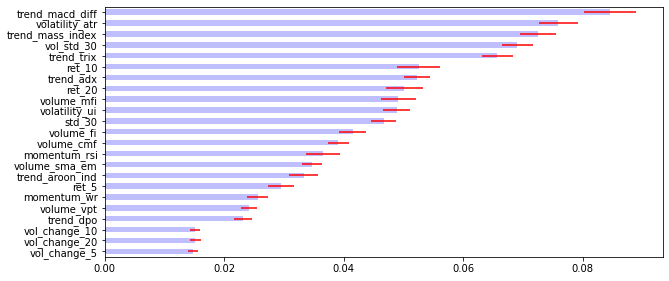

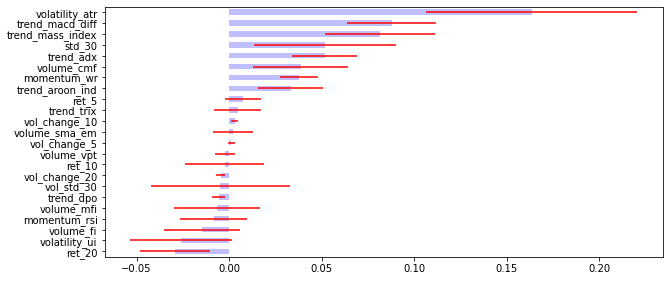

In [25]:
# Q. 코드를 작성해주세요

# feat_imp 확인
plot_feature_importance(feat_imp)

# feat_imp_mda 확인
plot_feature_importance(feat_imp_mda)

## 해석 포인트
### - 두 방법에서 공통으로 상위에 있는 feature 
    - volatility_atr
    - trend_macd_diff
    - trend_mass_index
    - std_30
    - trend_trix

- → 트리 내부 분기 기준에서도 중요, 실제 예측 성능 기준에서도 중요 즉, **진짜로 모델에 기여하는 핵심 변수들**



### - MDI는 높은데 MDA는 낮은 feature
    - ret_10
    - ret_20
    - vol_std_30
    - volume_mfi
    - volatility_ui
    - vol_dpo

- → 트리 분기에서는 자주 사용됨 (MDI 높음) 하지만 실제 예측 성능에는 크게 기여하지 않음 (MDA 낮음)
- 트리에서만 중요해 보이는 가짜 중요 변수 가능성, 제거 고려
- **상관성 때문에 선택된 변수일 가능성 높음, 보조 변수**



### - MDA에서 상위인데 MDI에서 낮은 변수
    - trend_cci
    - momentum_wr
    - momentum_em
    - trend_aroon_ind


- → 트리 분기 과정에서는 많이 안 쓰였지만 실제로 섞으면 성능이 많이 떨어짐
- 실제 예측력은 있는데 트리 구조상 덜 선택된 변수 
- **비선형 구조에서 의미 있는 변수 가능성, 숨은 실력자**


- => MDA 기준으로 feature selection 하는 것이 더 신뢰성 있음. MDI는 트리 구조 편향이고 MDA는 실제 성능 기반이기때문



RFE CV, Recursive Feature Elimination

In [1]:
# Q. 코드를 작성해주세요

# RFE CV, Recursive Feature Elimination
# 기본 모델 (선형 SVC여야 coef_ 사용 가능)
# svc_rbf = SVC(kernel='linear', probability=True) 
# # RFECV 객체 생성
# rfe_cv = RFECV(svc_rbf, cv=cv)
# # 학습
# rfe_fitted = rfe_fitted = rfe_cv.fit(X, y) # fit

In [2]:
# 선택된 피쳐 확인하기

selected_features = X.columns[rfe_fitted.support_]
print("선택된 feature:")
print(selected_features)

NameError: name 'X' is not defined

SFS, Sequential Feature Selection

In [4]:
# SFS, Sequential Feature Selection

 n = 10
sfs_forward = SequentialFeatureSelector(svc_rbf, n_features_to_select=n, direction='forward')
sfs_fitted = sfs_forward.fit(X_sc, y)

IndentationError: unexpected indent (947186799.py, line 3)

In [ ]:
# 선택된 피쳐 확인하기

selected_features = X.columns[sfs_fitted.get_support()]
print("선택된 feature:")
print(selected_features)

SHAP, Shapley Additive explanations

In [ ]:
# Q. 코드를 작성해주세요

# SHAP, Shapley Additive explanations
import shap
explainer = shap.TreeExplainer(rfc)
shap_value = explainer.shap_values(X_sc)

# shap_value, X_sc 사용 shap.summary_plot 그리기
shap.summary_plot(
    shap_value,      # 계산된 shap value
    X_sc,            # 입력 데이터
    feature_names=X.columns  # 컬럼명 표시
)

## 3. 프로젝트 : Model Traning
### ① 환경구성 및 데이터 불러오기
### ② Purged K-fold for Cross-Validation적용하기
### ③ Model 적용하기



### ① 환경구성 및 데이터 불러오기

In [5]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve

sys.path.append('/aiffel/aiffel/fnguide/data/')
from libs.mlutil.pkfold import PKFold

In [16]:
# 데이터 경로 설정 및 pickle 파일 불러오기
DATA_PATH = '/aiffel/aiffel/fnguide/data/'
data_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')


In [19]:
# 파일 불러오기
df_data = pd.read_pickle(data_file_name)

# 확인
df_data['t_value'].value_counts()

 1.0    481
-1.0    252
-0.0    224
Name: t_value, dtype: int64

In [20]:
# 여기서부터 모델에 적용하기 위한 데이터 정제화를 시작합니다.
df_data['t_value'].value_counts()

# 데이터셋 비율 나누기
train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test = int(np.round(len(df_data) * test_ratio))

X, y = df_data.iloc[:, 5:-1], df_data.iloc[:, -1]

# standardzation
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# 데이터셋 분리
train_x, test_x, train_y, test_y = X_sc[:n_train, :], X_sc[-n_test:, :], y.iloc[:n_train], y.iloc[-n_test:]

train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_x = pd.DataFrame(test_x, index=test_y.index, columns=X.columns)
test_y = pd.Series(test_y, index=test_y.index)

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
train_x = train_x[:1000] # 데이터셋을 증가 혹은 감소시켜 결과를 비교해봅시다.
train_y = train_y[:1000]

### ② Purged K-fold for Cross-Validation적용하기

In [28]:
# Q. 코드를 작성해주세요
from libs.mlutil.pkfold import PKFold

n_cv =4 # 앞에서 지정한 값은 4입니다. 얼마를 넣을지 생각해보고 왜 이 값을 넣었는지에 대해서 설명해봅시다.
# t1 = pd.Series(train_y.index.values, index=train_y.index)

# # purged K-Fold 
# cv = PKFold(
#     n_splits=n_cv,
#     embargo_pct=0.01  # 1% embargo (보통 0~0.05 사용)
# )


#__init__() got an unexpected keyword argument 't1'로 에러가 계속 나서 AI 도움을 받아 수정함

# samples_info_sets 생성
samples_info_sets = pd.Series(
    data=train_y.index,     # 종료 시점
    index=train_y.index     # 시작 시점
)

# Purged K-Fold
cv = PKFold(
    n_splits=n_cv,
    samples_info_sets=samples_info_sets,
    pct_embargo=0.01
)

### 왜 4를 쓰는가?

- Purged KFold는 시
    - 시간 순서 유지
    - 미래 정보 누출 방지
    - 각 fold 사이 purge(정리) 구간 필요
- 시계열 데이터는 fold가 많을수록 → 각 fold train 구간이 너무 짧아짐
- 그래서 균형적인 4를 선택 많이 한다

In [27]:
help(PKFold)


Help on class PKFold in module libs.mlutil.pkfold:

class PKFold(sklearn.model_selection._split.KFold)
 |  PKFold(n_splits: int = 3, samples_info_sets: pandas.core.series.Series = None, pct_embargo: float = 0.0)
 |  
 |  Extend KFold class to work with labels that span intervals
 |  
 |  The train is purged of observations overlapping test-label intervals
 |  Test set is assumed contiguous (shuffle=False), w/o training samples in between
 |  
 |  :param n_splits: (int) The number of splits. Default to 3
 |  :param samples_info_sets: (pd.Series) The information range on which each record is constructed from
 |      *samples_info_sets.index*: Time when the information extraction started.
 |      *samples_info_sets.value*: Time when the information extraction ended.
 |  :param pct_embargo: (float) Percent that determines the embargo size.
 |  
 |  Method resolution order:
 |      PKFold
 |      sklearn.model_selection._split.KFold
 |      sklearn.model_selection._split._BaseKFold
 |      

### ③ Model 적용하기

In [29]:
# GridsearchCV에서 사용할 파라미터 설정합니다. 파라미터값을 바꿔보세요
bc_params = {'n_estimators': [5, 10, 20],
             'max_features': [0.5, 0.7],
             'base_estimator__max_depth': [3,5,10,20],
             'base_estimator__max_features': [None, 'auto'],
             'base_estimator__min_samples_leaf': [3, 5, 10],
             'bootstrap_features': [False, True]
            }

In [30]:
# RandomForest 사용
rfc = RandomForestClassifier(class_weight='balanced')

In [31]:
# Q. 코드를 작성해주세요

# Bagging 적용
bag_rfc = BaggingClassifier(
    base_estimator=rfc,
    n_estimators=10,
    max_features=0.7,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=42
)

| 파라미터               | 의미                           |
| ------------------ | ---------------------------- |
| base_estimator=rfc | RandomForest를 기본 모델로 사용      |
| n_estimators       | bagging 횟수                   |
| max_features       | 각 bagging 모델에 들어갈 feature 비율 |
| bootstrap          | 샘플링 허용                       |
| bootstrap_features | feature도 랜덤 샘플링 여부           |
| n_jobs=-1          | 병렬 처리                        |


### 금융 시계열 관점 핵심

Bagging + RandomForest는
- 분산 감소
- 과적합 완화
- 불균형 데이터에서 안정적

특히 lass_weight='balanced' 설정은 상승/하락 비율 불균형에서 매우 중요합니다.

In [32]:
# Q. 코드를 작성해주세요

# GridSearchCV 적용
gs_rfc =GridSearchCV(
    estimator=bag_rfc,
    param_grid=bc_params,
    scoring='f1',     # 금융 분류 문제 → f1 추천
    cv=cv,            # Purged KFold 사용
    n_jobs=-1,
    verbose=1
)

# 학습
gs_rfc.fit(train_x, train_y)

print("Best Parameters:", gs_rfc.best_params_)
print("Best CV Score:", gs_rfc.best_score_)

Fitting 4 folds for each of 288 candidates, totalling 1152 fits


/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:771: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 762, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 216, in __call__
    return self._score(
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 264, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py", line 1113, in f1_score
    return fbeta_score(
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py", line 1251, in fbeta_score
    _, _, f, _ = precision_recall_fscore_support(
  File "/opt/conda/lib/pyt

Best Parameters: {'base_estimator__max_depth': 3, 'base_estimator__max_features': None, 'base_estimator__min_samples_leaf': 3, 'bootstrap_features': False, 'max_features': 0.5, 'n_estimators': 5}
Best CV Score: nan


### 왜 scoring='f1' 인가?

- 금융 방향성 예측은 보통 상승/하락 불균형 존재하고, accuracy는 의미 없음, precision/recall 균형 중요
- -> 그래서 F1 score 사용

In [35]:
# fit
gs_rfc.fit(train_x, train_y)

# best estimator 
gs_rfc_best = gs_rfc.best_estimator_
gs_rfc_best.fit(train_x, train_y)

Fitting 4 folds for each of 288 candidates, totalling 1152 fits


/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:771: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 762, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 216, in __call__
    return self._score(
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 264, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py", line 1113, in f1_score
    return fbeta_score(
  File "/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py", line 1251, in fbeta_score
    _, _, f, _ = precision_recall_fscore_support(
  File "/opt/conda/lib/pyt

BaggingClassifier(base_estimator=RandomForestClassifier(class_weight='balanced',
                                                        max_depth=3,
                                                        max_features=None,
                                                        min_samples_leaf=3),
                  max_features=0.5, n_estimators=5, n_jobs=-1, random_state=42)

In [36]:
# 예측값 확인
pred_y = gs_rfc_best.predict(test_x)
prob_y = gs_rfc_best.predict_proba(test_x)

In [38]:
# Q. 코드를 작성해주세요
from sklearn.metrics import precision_score, recall_score, f1_score
# test_y, pred_y를 활용한 지표 적용
confusion = confusion_matrix(test_y, pred_y)
accuracy  = accuracy_score(test_y, pred_y) 
precision = precision_score(test_y, pred_y, average='macro') 
recall    = recall_score(test_y, pred_y, average='macro')
f1        = f1_score(test_y, pred_y, average='macro')

# 지표를 통한 결과 확인
print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'정확도:{accuracy:.4f}')
print(f'정밀도:{precision:.4f}')
print(f'재현율:{recall:.4f}')
print(f'F1-score:{f1:.4f}')


================= confusion matrix ====================
[[43 15 21]
 [15 19 23]
 [ 4  7 44]]
정확도:0.5550
정밀도:0.5523
재현율:0.5592
F1-score:0.5377


In [2]:
# Q. 코드를 작성해주세요

# ROC curve 만들기
fpr, tpr, thresholds = roc_curve(test_y, prob_y[:, 1])
auc = roc_auc_score(test_y, prob_y, multi_class='ovr')

# ROC curve 시각화
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
plt.xlabel('fpr')
plt.ylabel('tpr')
print(f'auc:{auc:.4f}')

NameError: name 'roc_curve' is not defined